# CH06_Probability

---
## 6.1: Probability
---

### 6.1.1: Frequentist versus Bayesian

### 6.1.2: Definition and Axioms

### 6.1.3: Permutations

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import comb, exp, factorial, log, perm

os.chdir('/home/user/repo/studies/qss/data')

In [2]:
def birthday(k):
    logdenom = k * log(365) + log(factorial(365 - k))
    lognumer = log(factorial(365))
    pr = 1 - exp(lognumer - logdenom)
    return pr

In [3]:
k = pd.Series(np.arange(1,51))

bday = k.apply(birthday)
bday.index = k

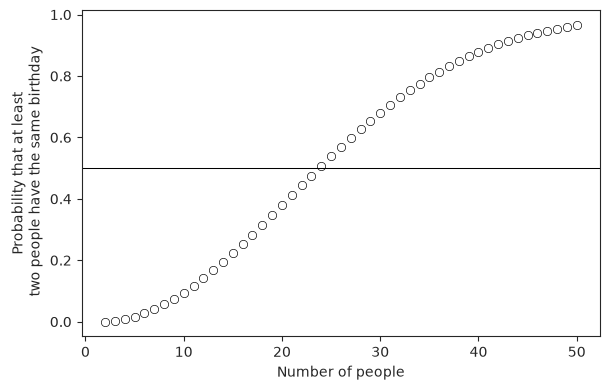

In [5]:
sns.set_style('ticks')

sns.relplot(
    x=k, y=bday, color='white', edgecolor='black', height=4, aspect=1.5
).set(ylabel='Probability that at least\n two people have the same birthday',
      xlabel='Number of people').despine(right=False, top=False)

plt.axhline(0.5, color='black', linewidth=.75);

In [7]:
bday[20:25]

21    0.443688
22    0.475695
23    0.507297
24    0.538344
25    0.568700
dtype: float64

### 6.1.4: Sampling With and Without Replacement

In [8]:
k = 23
sims = 10000
event = 0

for i in range(sims):
    days = np.random.choice(np.arange(1,366), size=k, replace=True)
    days_unique = np.unique(days)

    if len(days_unique) < len(days):
        event += 1

answer = event / sims
answer

0.5055

### 6.1.5: Combinations

In [18]:
comb(20,5)

15504

In [19]:
comb(10,0)

1

In [20]:
comb(10,5)

252

In [21]:
252/15504

0.016253869969040248

In [23]:
comb(10,1) * comb(10,4) / comb(20,5)

0.13544891640866874

In [24]:
1 - (comb(10,0) * comb(10,5) / comb(20,5)) - (comb(10,1) * comb(10,4) / comb(20,5))

0.848297213622291

In [26]:
comb(84,6)

406481544

In [27]:
12 / comb(84,6)

2.952163555056758e-08

---
## 6.2: Conditional Probability
---

### 6.2.1: Conditional, Marginal, and Joint Probabilities

In [31]:
FLVoters = pd.read_csv('FLVoters.csv')
FLVoters.shape

(10000, 6)

In [32]:
FLVoters.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   surname  9999 non-null   str    
 1   county   10000 non-null  int64  
 2   VTD      10000 non-null  int64  
 3   age      9992 non-null   float64
 4   gender   9992 non-null   str    
 5   race     9126 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 468.9 KB


In [34]:
FLVoters[FLVoters['surname'].isnull()]

,surname,county,VTD,age,gender,race
349,NaN,5,14,70.0,f,white


In [35]:
FLVoters.head()

,surname,county,VTD,age,gender,race
0,PIEDRA,115,66,58.0,f,white
1,LYNCH,115,13,51.0,m,white
2,CHESTER,115,103,63.0,m,NaN
3,LATHROP,115,80,54.0,m,white
4,HUMMEL,115,8,77.0,f,white


In [39]:
FLVoters['surname'] = np.where(
    FLVoters['surname'].isnull(), 'NULL', FLVoters['surname'])

In [42]:
FLVoters.loc[[349]]

,surname,county,VTD,age,gender,race
349,NULL,5,14,70.0,f,white


In [44]:
FLVoters = FLVoters.dropna()
FLVoters.shape

(9113, 6)

In [45]:
margin_race = FLVoters['race'].value_counts(normalize=True).sort_index()
margin_race

race
asian       0.019203
black       0.131022
hispanic    0.130802
native      0.003182
other       0.034017
white       0.681773
Name: proportion, dtype: float64

In [46]:
margin_gender = FLVoters['gender'].value_counts(normalize=True).sort_index()
margin_gender

gender
f    0.535828
m    0.464172
Name: proportion, dtype: float64

In [48]:
FLVoters.loc[FLVoters.gender == 'f', 'race'].value_counts(normalize=True).sort_index()

race
asian       0.016998
black       0.138849
hispanic    0.136392
native      0.003481
other       0.032357
white       0.671923
Name: proportion, dtype: float64

In [49]:
joint_p = pd.crosstab(FLVoters.race, FLVoters.gender, normalize=True)
joint_p

gender,f,m
race,,
asian,0.009108,0.010095
black,0.074399,0.056622
hispanic,0.073082,0.057720
native,0.001865,0.001317
other,0.017338,0.016679
white,0.360035,0.321738


In [55]:
joint_p.sum(axis=1)

race
asian       0.019203
black       0.131022
hispanic    0.130802
native      0.003182
other       0.034017
white       0.681773
dtype: float64

In [56]:
joint_p.sum()

gender
f    0.535828
m    0.464172
dtype: float64

In [58]:
pd.crosstab(FLVoters.race, FLVoters.gender, normalize=True, margins=True)

gender,f,m,All
race,,,
asian,0.009108,0.010095,0.019203
black,0.074399,0.056622,0.131022
hispanic,0.073082,0.057720,0.130802
native,0.001865,0.001317,0.003182
other,0.017338,0.016679,0.034017
white,0.360035,0.321738,0.681773
All,0.535828,0.464172,1.000000


In [59]:
conditions = [
    (FLVoters.age <= 20),
    (FLVoters.age > 20) & (FLVoters.age <= 40),
    (FLVoters.age > 40) & (FLVoters.age <= 60)
]

choice = [1, 2, 3]

FLVoters['age_group'] = np.select(conditions, choice, 4)

In [ ]:
joint3 = pd.crosstab([FLVoters.race, FLVoters.age_group], FLVoters.gender, normalize=True)
joint3

gender                     f         m
race     age_group                    
asian    1          0.000110  0.000219
         2          0.002634  0.002853
         3          0.004170  0.005157
         4          0.002195  0.001865
black    1          0.001646  0.001646
         2          0.028092  0.022825
         3          0.025787  0.018984
         4          0.018874  0.013168
hispanic 1          0.001536  0.001646
         2          0.026007  0.019752
         3          0.027324  0.022166
         4          0.018216  0.014156
native   1          0.000110  0.000000
         2          0.000439  0.000439
         3          0.000658  0.000329
         4          0.000658  0.000549
other    1          0.000329  0.000439
         2          0.006255  0.006913
         3          0.005816  0.005596
         4          0.004938  0.003731
white    1          0.005926  0.004060
         2          0.079666  0.075058
         3          0.126084  0.118402
         4          0.148359  0.124218

In [61]:
pd.crosstab([FLVoters.race, FLVoters.age_group], FLVoters.gender, normalize=True, margins=True)

gender                     f         m       All
race     age_group                              
asian    1          0.000110  0.000219  0.000329
         2          0.002634  0.002853  0.005487
         3          0.004170  0.005157  0.009327
         4          0.002195  0.001865  0.004060
black    1          0.001646  0.001646  0.003292
         2          0.028092  0.022825  0.050916
         3          0.025787  0.018984  0.044771
         4          0.018874  0.013168  0.032042
hispanic 1          0.001536  0.001646  0.003182
         2          0.026007  0.019752  0.045759
         3          0.027324  0.022166  0.049490
         4          0.018216  0.014156  0.032371
native   1          0.000110  0.000000  0.000110
         2          0.000439  0.000439  0.000878
         3          0.000658  0.000329  0.000988
         4          0.000658  0.000549  0.001207
other    1          0.000329  0.000439  0.000768
         2          0.006255  0.006913  0.013168
         3          0.005816  0.005596  0.011412
         4          0.004938  0.003731  0.008669
white    1          0.005926  0.004060  0.009986
         2          0.079666  0.075058  0.154724
         3          0.126084  0.118402  0.244486
         4          0.148359  0.124218  0.272578
All                 0.535828  0.464172  1.000000

In [62]:
margin_age = FLVoters['age_group'].value_counts(normalize=True).sort_index()
margin_age

age_group
1    0.017667
2    0.270932
3    0.360474
4    0.350927
Name: proportion, dtype: float64

In [64]:
joint3.index[:3]

MultiIndex([('asian', 1),
            ('asian', 2),
            ('asian', 3)],
           names=['race', 'age_group'])

In [71]:
joint3.loc[('black', 4), 'f'] / margin_age[4]

np.float64(0.05378361475922452)

In [72]:
joint2 = pd.crosstab(FLVoters['age_group'], FLVoters['gender'], normalize=True, margins=True)
joint2

gender,f,m,All
age_group,,,
1,0.009657,0.008011,0.017667
2,0.143092,0.127839,0.270932
3,0.189839,0.170635,0.360474
4,0.193240,0.157687,0.350927
All,0.535828,0.464172,1.000000


In [73]:
joint2.loc[4,'f']

np.float64(0.1932404257653901)

In [74]:
0.018874 / 0.193240

0.097671289588077

In [75]:
joint3.loc[('black', 4), 'f'] / joint2.loc[4, 'f']

np.float64(0.097671777399205)

### 6.2.2: Independence

In [76]:
margin_race

race
asian       0.019203
black       0.131022
hispanic    0.130802
native      0.003182
other       0.034017
white       0.681773
Name: proportion, dtype: float64

In [78]:
margin_gender

gender
f    0.535828
m    0.464172
Name: proportion, dtype: float64

In [79]:
joint_p

gender,f,m
race,,
asian,0.009108,0.010095
black,0.074399,0.056622
hispanic,0.073082,0.057720
native,0.001865,0.001317
other,0.017338,0.016679
white,0.360035,0.321738


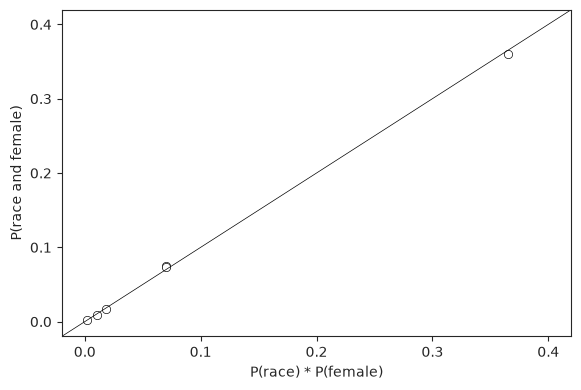

In [80]:
lims = (-0.02, 0.42)
ticks = [0, .1, .2, .3, .4]

sns.relplot(
    x=margin_race * margin_gender['f'], y=joint_p['f'],
    color='white', edgecolor='black', height=4, aspect=1.5
).set(xlabel='P(race) * P(female)', ylabel='P(race and female)',
      xlim=lims, ylim=lims, xticks=ticks, yticks=ticks).despine(right=False, top=False)

plt.gca().axline((0,0), slope=1, color='black', linewidth=.5);

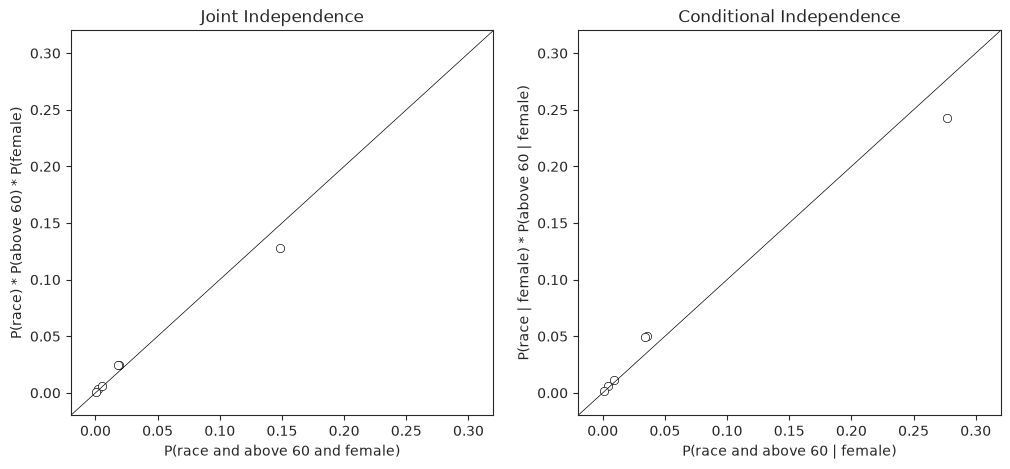

In [102]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

lims = (-0.02, 0.32)

sns.scatterplot(
    x=joint3.loc[(slice(None), 4), 'f'].droplevel('age_group'),
    y=margin_race * margin_age[4] * margin_gender['f'],
    color='white', edgecolor='black', ax=axs[0]
).set(xlabel='P(race and above 60 and female)', 
      ylabel='P(race) * P(above 60) * P(female)',
      title='Joint Independence', xlim=lims, ylim=lims)

axs[0].axline((0,0), slope=1, color='black', linewidth=.5)

sns.scatterplot(
    x=(joint3.loc[(slice(None), 4), 'f'] / margin_gender['f']).droplevel('age_group'),
    y=((joint_p['f'] / margin_gender['f']) * (joint2.loc[4, 'f'] / margin_gender['f'])),
    color='white', edgecolor='black', ax=axs[1]
).set(xlabel='P(race and above 60 | female)', 
      ylabel='P(race | female) * P(above 60 | female)',
      title='Conditional Independence', xlim=lims, ylim=lims)

axs[1].axline((0,0), slope=1, color='black', linewidth=.5)

In [115]:
sims = 1000
doors = np.array(['goat', 'goat', 'car'])

result_switch = np.empty(sims, dtype=doors.dtype)
result_noswitch = np.empty(sims, dtype=doors.dtype)

In [116]:
for i in range(sims):
    # randomly choose the initial door
    first = np.random.choice(np.arange(0,3))
    result_noswitch[i] = doors[first]
    remain = np.delete(doors, first) # remaining two doors
    if doors[first] == 'car': # two goats left
        monty = np.random.choice(np.arange(0,2))
    else: # one goat and one car left
        monty = np.arange(0,2)[remain=='goat']
    result_switch[i] = np.delete(remain, monty)[0]

In [117]:
(result_noswitch == 'car').mean()

np.float64(0.319)

In [118]:
(result_switch == 'car').mean()

np.float64(0.681)

### 6.2.3: Bayes' Rule